# Разработка A/B-тестирования и анализ результатов

***Цель:***  Ознакомиться с историческими данными и рассчитать параметры A/B-теста для проверки алгоритма рекомендаций, который, по мнению заказчика, будет показывать более интересный контент для каждого пользователя.

***Задачи:*** 

* Первичное знакомство с историческими данными
* Подготовка к проведению теста
* Формирование гипотиз
* Проверка гипотиз и формирование итоговых выводов


## Описание данных

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных


In [1]:
# импорт библиотеки pandas
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt

# Загружаем модули для расчета размера выборки и анализа мощности A/B‑теста
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

# Загружаем модули для округления вверх
from math import ceil

# Проводим Z-тест пропорций
from statsmodels.stats.proportion import proportions_ztest


In [2]:
# Загрузка датасета с историческими данными
sessions_history = pd.read_csv('sessions_project_history.csv')
sessions_history.head(5)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными


In [3]:
# Производим подсчет sessions для каждого user_id
result = sessions_history.groupby('user_id').agg(count = ('session_id', 'nunique')).reset_index()

# Создаем переменную, содержащую данные о user_id с самым большим количеством sessions(с одним из нескольких)
user_id_max_sessions = result.sort_values(by='count', ascending = False)['user_id'].head(1).iloc[0]

# Выводим данные об одном из пользователей с самым большим количеством session
sessions_history[sessions_history['user_id'] == user_id_max_sessions]

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций

Используя исторические данные, визуализируем, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, проанализируем количество зарегистрированных активных пользователей за каждый день без накопления.

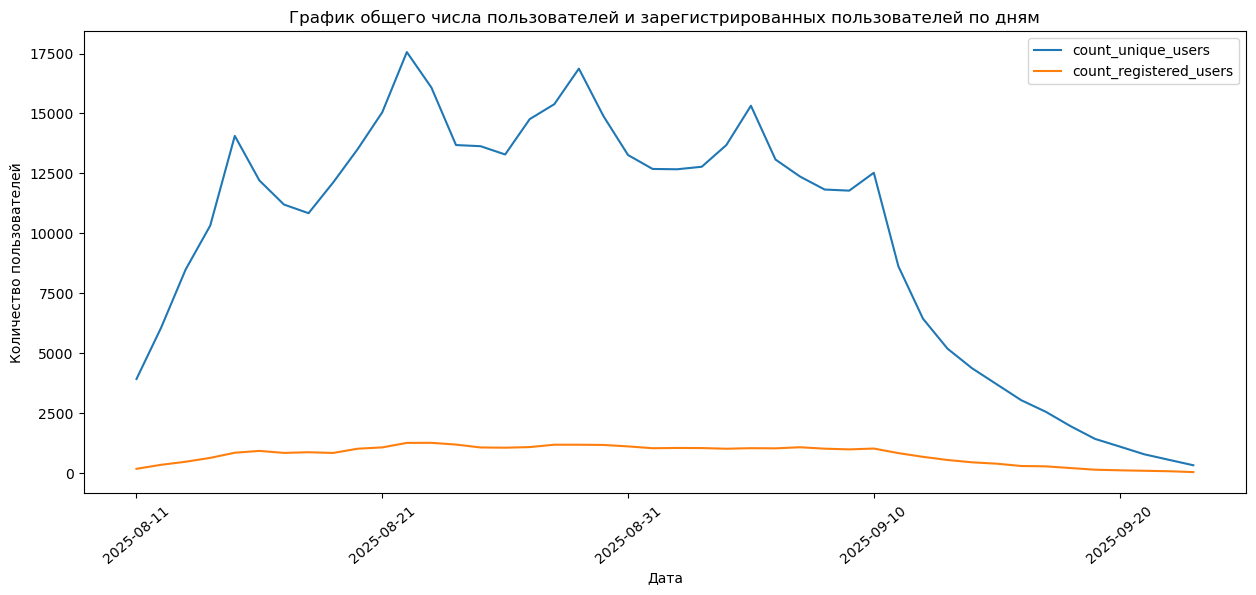

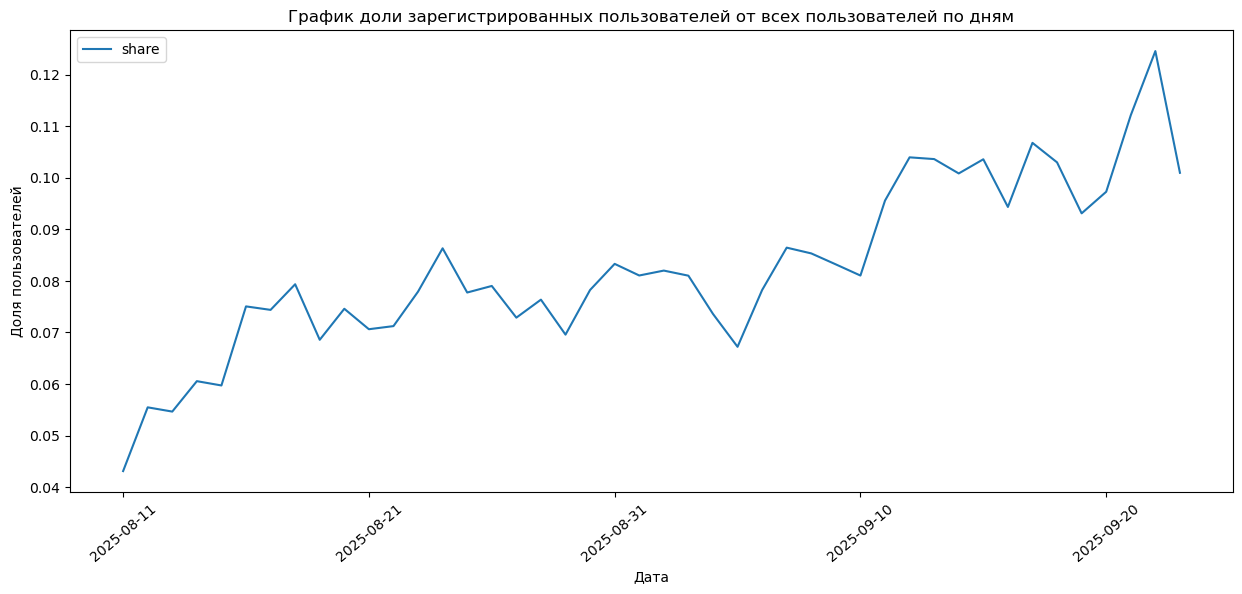

In [4]:
# Произведем расчет уникальных пользователей и число зарегистрированных по дням

df = (sessions_history.groupby('session_date').agg(
    count_unique_users = ('user_id', 'nunique'),            # Зарегистрированные
    count_registered_users = ('registration_flag','sum')    # Уникальные пользователи
).reset_index())




# Строим 1-й линейный график для пользователей и зарегистрированных пользователей по дням
df.plot(kind = 'line',
        x = 'session_date',
        y = ['count_unique_users', 'count_registered_users'],
        figsize = (15, 6),
        rot = 40)

# Настраиваем оформление графика
plt.title('График общего числа пользователей и зарегистрированных пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Количество пользователей')

# Расчитываем долю зарегистрированных пользователей от всех пользователей по дням
df['share'] = df['count_registered_users']/df['count_unique_users']



# Строим 2-й линейный график для доли зарегистрированных пользователей к общиму числу пользователей в этот день
df.plot(kind = 'line',
        x = 'session_date',
        y = ['share'],
        figsize = (15, 6),
        rot = 40)

# Настраиваем оформление графика
plt.title('График доли зарегистрированных пользователей от всех пользователей по дням')
plt.xlabel('Дата')
plt.ylabel('Доля пользователей')

plt.show()


Из графика видим рост зарегистрированных пользователей к общему числу пользователей

#### 1.4. Анализ числа просмотренных страниц

Проанализируем число просмотренных страниц во время первых сессий пользователей. 

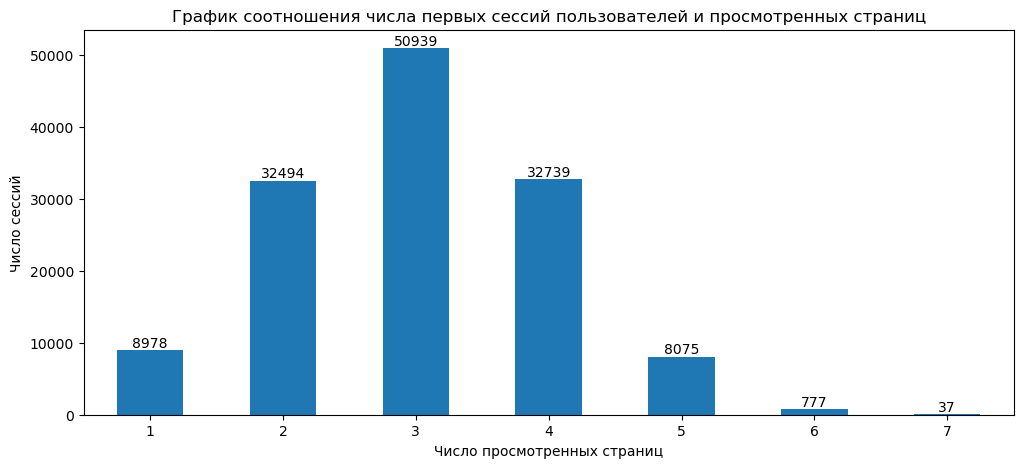

In [5]:
# Считаем количество сессий для каждого параметра просмотренных страниц
page_counter_per_session = (
    sessions_history[sessions_history['session_number'] == 1]
    .groupby('page_counter').agg(count_sessions = ('session_id', 'count'))
)

# Строим столбчатую диаграмму
ax = page_counter_per_session.plot(
    kind = 'bar',
    rot = 0,
    legend = False,
    figsize = (12, 5)
)

# Подписываем каждую колонку числом сверху
for p, label in zip(ax.patches, page_counter_per_session['count_sessions']):
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2, height, f'{label:.0f}', ha='center', va='bottom')

# Настраиваем оформление графика
plt.title('График соотношения числа первых сессий пользователей и просмотренных страниц')
plt.xlabel('Число просмотренных страниц')
plt.ylabel('Число сессий')
    
plt.show()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц

Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта, следовательно создадим отдельный столбец `good_session`, содержащий сведения о просмотре 4 и более страниц(значение `1`) и менее 4 страниц (значение `0`).

Проверим как менялась доля успешных сессий по дням относительно средней доли успешных сессий. 

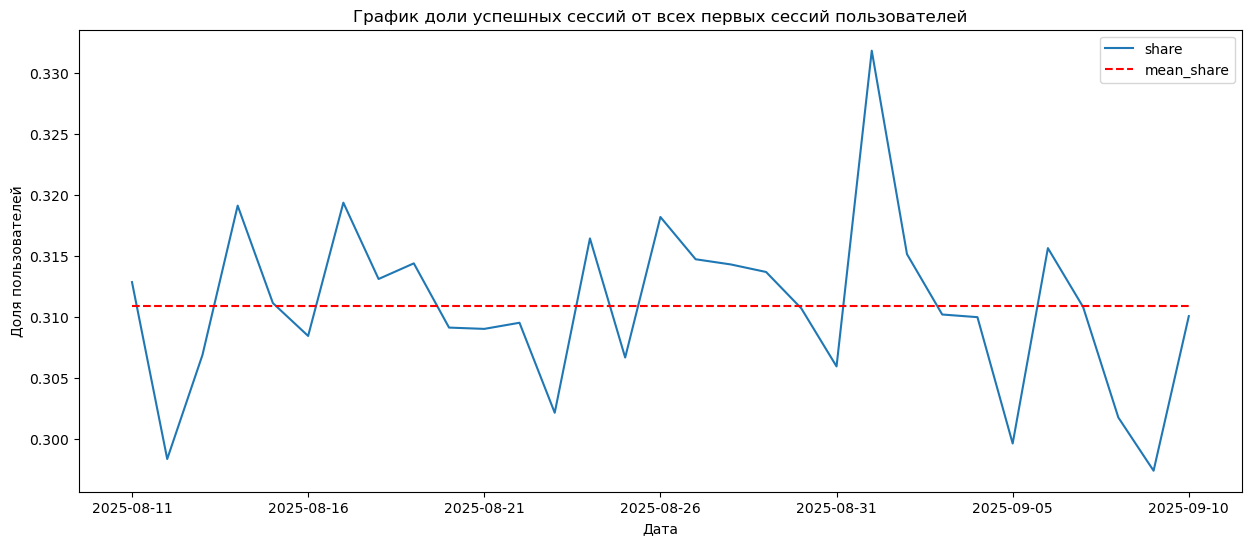

In [6]:
# Создаем новый столбец со значение 1, если за одну сессию было просмотрено 4 и более страницы, в обратном случае 0
sessions_history['good_session'] = (sessions_history['page_counter'] >= 4).astype('int64')

# Считаем количество первых сессий и количество успешных(просмотр 4 и более страниц) первых сессий по дням
df = (sessions_history[sessions_history['session_number'] == 1]
      .groupby('session_date').agg(count_session = ('good_session', 'count'),
                                 count_good_session = ('good_session', 'sum')
                                 )
     ).reset_index()


# Считаем долю успешных сессий
df['share'] = df['count_good_session']/df['count_session']

# Считаем среднюю долю успешных сессий
df['mean_share'] = df['share'].mean()

# Строим  линейный график 
df.plot(kind = 'line',
        x = 'session_date',
        y = ['share', 'mean_share'],
        figsize = (15, 6),
        rot = 0,
        style={'mean_share': 'r--'})  # 'r--' — красная пунктирная линия

# Настраиваем оформление графика
plt.title('График доли успешных сессий от всех первых сессий пользователей')
plt.xlabel('Дата')
plt.ylabel('Доля пользователей')

plt.show()

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки


In [7]:
# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p1 = df['share'].mean() # Базовый уровень доли
mde = p1*0.03  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p1, p1 + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 38983


#### 2.2. Расчёт длительности A/B-теста


In [8]:
# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = ((sessions_history.groupby('session_date').agg(count_unique_users = ('user_id', 'nunique'))) 
                    ['count_unique_users'].mean())

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size*2/avg_daily_users)

print(f"Рассчитанная длительность A/B-теста при текущем уровене трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровене трафика в 9907.363636363636 пользователей в день составит 8 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе убедимся, что всё идёт по плану: пользователи разделены правильным образом, а интересующие метрики корректно считаются.


Количество пользователей в группе A: 1477
Количество пользователей в группе B: 1466
Процентная разница: 0.74%


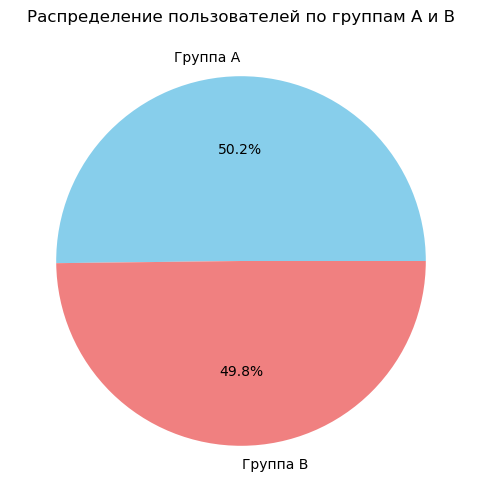

In [9]:
# Загрузка датасета с историческими данными sessions_project_test_part.csv
sessions_test_part = pd.read_csv('sessions_project_test_part.csv')

# Осуществляем расчет уникальных пользователей в Группе А и В
test_group_a = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'].nunique()
test_group_b = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'].nunique()

# Осуществляем расчёта процентной разницы
p = 100 * (abs(test_group_a - test_group_b) / test_group_a)

# Выводим результаты на экран
print(f"Количество пользователей в группе A: {test_group_a}")
print(f"Количество пользователей в группе B: {test_group_b}")
print(f"Процентная разница: {p:.2f}%")

# Данные для визуализации
users_count = [test_group_a, test_group_b]
groups = ['Группа A', 'Группа B']

# Строим график
plt.figure(figsize=(8, 6))
plt.pie(users_count, labels=groups, autopct='%1.1f%%', colors=['skyblue', 'lightcoral'])

plt.title('Распределение пользователей по группам A и B')

plt.show()

#### 3.2. Проверка пересечений пользователей


In [10]:
# Составляем массив пользователей в Группе А и Группе В для дальнейшего сравнения
test_group_a = sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id']
test_group_b = sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id']

# Осуществляем сопоставление пользователей в Группах А и В, осуществляем вывод количества пересекающихся пользователей 
intersection = len(set(test_group_a) & set(test_group_b))
print(f"Количество пересекающихся пользователей в группе А и группе В составляет: {intersection}")

Количество пересекающихся пользователей в группе А и группе В составляет: 0


#### 3.3. Равномерность разделения пользователей по устройствам
Убедимся в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.


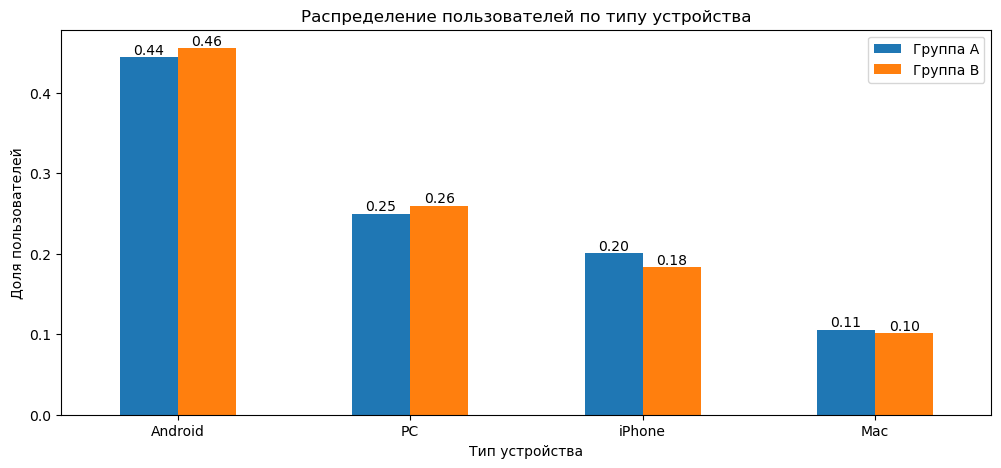

In [11]:
# Убираем дубликаты
drop = sessions_test_part.drop_duplicates('user_id')

#Группируем данные для групп и расчитываем долю пользователей для каждого устройства
df = drop.pivot_table(index = 'device',
                     columns = 'test_group',
                     values = 'user_id',
                     aggfunc = 'count')

#расчитываем долю пользователей для каждого устройства
df['count_group_a'], df['count_group_b'] = df['A'].sum(), df['B'].sum()
df['share_a'], df['share_b'] = df['A']/df['count_group_a'], df['B']/df['count_group_b']

#Сортируем по столбцу доли группы А (share_a)
df = df.sort_values(by = 'share_a', ascending = False)

# Построим график столбчатой диаграммы A
ax = df[['share_a', 'share_b']].plot(kind = 'bar',
        rot = 0,
        legend = False,
        figsize = (12, 5)
       )

# Подписываем столбцы для share_a
for p, label in zip(ax.patches[:len(df)], df['share_a']):
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f'{label:.2f}',
        ha='center',
        va='bottom'
    )

# Подписываем столбцы для share_b
for p, label in zip(ax.patches[len(df):], df['share_b']):
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f'{label:.2f}',
        ha='center',
        va='bottom'
    )
    
# Настраиваем оформление графика
plt.title('Распределение пользователей по типу устройства')
plt.legend(['Группа A', 'Группа B'])
plt.xlabel('Тип устройства')
plt.ylabel('Доля пользователей')

plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедимся, что пользователи равномерно распределены по регионам.


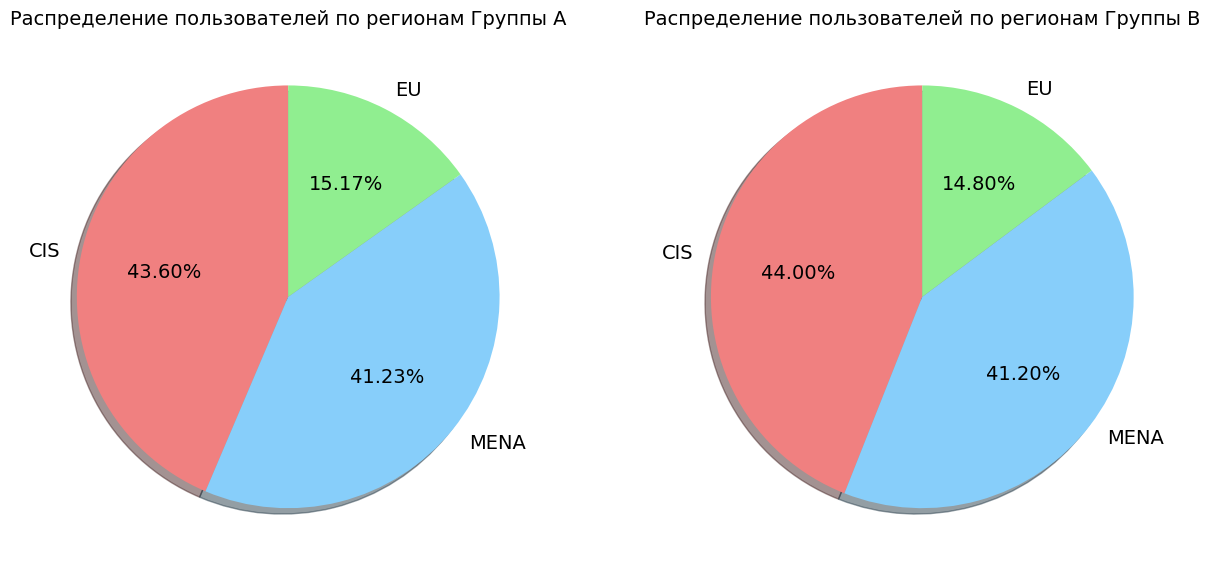

In [12]:
#Группируем данные для группы А и расчитываем долю пользователей для каждого региона
group_a =drop[drop['test_group'] == 'A'].groupby('region').agg(count = ('user_id', 'count'))
group_a['count_group'] = group_a['count'].sum()
group_a['share'] = group_a['count']/group_a['count_group']
group_a = group_a.sort_values(by = 'share', ascending = False)

#Группируем данные для группы В и расчитываем долю пользователей для каждого региона
group_b =drop[drop['test_group'] == 'B'].groupby('region').agg(count = ('user_id', 'count'))
group_b['count_group'] = group_b['count'].sum()
group_b['share'] = group_b['count']/group_b['count_group']
group_b = group_b.sort_values(by = 'share', ascending = False)

# Создаём 1×2 сетку графиков
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Первый график: круговая диаграмма группы А
axes[0].pie(
    group_a['share'],
    labels=group_a.index,
    colors=['lightcoral', 'lightskyblue', 'lightgreen'],
    autopct='%1.2f%%',      # отображаем проценты
    shadow=True,            # добавляем тень
    startangle=90,         # поворачиваем на 90°
    textprops={'fontsize': 14}  # размер шрифта подписей
)
axes[0].set_title('Распределение пользователей по регионам Группы A', fontsize=14)

# Первый график: круговая диаграмма группы В
axes[1].pie(
    group_b['share'],
    labels=group_b.index,
    colors=['lightcoral', 'lightskyblue', 'lightgreen'],
    autopct='%1.2f%%',      # отображаем проценты
    shadow=True,            # добавляем тень
    startangle=90,         # поворачиваем на 90°
    textprops={'fontsize': 14}  # размер шрифта подписей
)
axes[1].set_title('Распределение пользователей по регионам Группы В', fontsize=14)

plt.show()


#### 3.5. Вывод после проверки A/B-теста


Различие в количестве пользователей в двух группах (группе A: 1477 и группе B: 1466) незначительное и является допустимым.
При этом выборки являются независимыми, пересечений выявлено не было, данные сохранились в исходном количестве уникальных пользователей для обоих групп. 

Распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам сохраняется равномерным, различия в процентном соотношении незначительны, не более 2% между соответсвующими категориальными переменными.

***Вывод:*** A/B-тест проходит корректно, нарушений не наблюдается. 

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики


In [13]:
# Загрузка датасета с историческими данными sessions_project_test.csv
sessions_test = pd.read_csv('sessions_project_test.csv')

# Создаем новый столбец со значение 1, если за одну сессию было просмотрено 4 и более страницы, в обратном случае 0
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype('int64')


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик
Перед проведением A/B-теста необходимо было определеться с нулевой и альтернативной гипотизой, для дальнейшего анализа вывожу определенные гипотизы, для дальнейшей проверки.

***Нулевая гипотеза(Н0):*** "доля успешных первых сессий на пользователя при использовании нового алгоритма не отличается статистически значимо от доли успешных первых сессий при использовании текущего алгоритма"
 H₀: μA = μB
 
***Альтернативная гипотиза(Н1):*** "доля успешных первых сессий на пользователя при использовании нового алгоритма статистически  выше, чем при использовании текущего алгоритма"
 H₁: μA < μB
 
целевая метрика: Доля успешных первых сессий

прокси-метрика: Рост числа регистраций пользователей

барьерная метрика: Отток после первой сессии — доля пользователей, не вернувшихся в приложение

#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

In [14]:
# Расчитываем массив с размерами выборок
n_a = sessions_test[(sessions_test['session_number'] == 1)&(sessions_test['test_group'] == 'A')].shape[0]
n_b = sessions_test[(sessions_test['session_number'] == 1)&(sessions_test['test_group'] == 'B')].shape[0]

# Расчитываем массив с количеством успехов выборки А и В
m_a = sessions_test[(sessions_test['session_number'] == 1)&(sessions_test['test_group'] == 'A')]['good_session'].sum()
m_b = sessions_test[(sessions_test['session_number'] == 1)&(sessions_test['test_group'] == 'B')]['good_session'].sum()

# Расчитываем долю успешных первых сессий для выборок
p_a, p_b = m_a/n_a, m_b/n_b 

# Разница между выборками
difference_ab = p_a - p_b

# Выводим результаты на экран
print(f"Массив выборки A: {n_a}")
print(f"Массив выборки B: {n_b}")
print(f"Массив с количеством успехов выборки А: {m_a}")
print(f"Массив с количеством успехов выборки B: {m_b}")
print(f"Доля успешных первых сессий в выборке A: {p_a}")
print(f"Доля успешных первых сессий в выборке B: {p_b}")
print(f"Разница между выборками: {difference_ab}")

Массив выборки A: 15162
Массив выборки B: 15416
Массив с количеством успехов выборки А: 4787
Массив с количеством успехов выборки B: 4851
Доля успешных первых сессий в выборке A: 0.31572351932462733
Доля успешных первых сессий в выборке B: 0.3146730669434354
Разница между выборками: 0.0010504523811919464


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 0.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

In [15]:

alpha = 0.05 # На каком уровне значимости проверяем гипотезу о равенстве вероятностей

stat_ztest, p_value_ztest = proportions_ztest(
    [m_a, m_b],
    [n_a, n_b],
    alternative='smaller' # так как H_1: p_a < p_b
)


if p_value_ztest > alpha:
    print(f'pvalue={p_value_ztest} > {alpha}')
    print('Нулевая гипотеза находит подтверждение!')
    print('Доля успешных первых сессий на пользователя при использовании нового алгоритма не отличается')
    print('статистически значимо от доли успешных первых сессий при использовании текущего алгоритма.')
else:
    print(f'pvalue={p_value_ztest} < {alpha}')
    print('Нулевая гипотеза не находит подтверждения!')
    print('Доля успешных первых сессий на пользователя при использовании нового алгоритма статистически выше,')
    print('чем при использовании текущего алгоритма')

pvalue=0.5783523649187868 > 0.05
Нулевая гипотеза находит подтверждение!
Доля успешных первых сессий на пользователя при использовании нового алгоритма не отличается
статистически значимо от доли успешных первых сессий при использовании текущего алгоритма.


#### 4.5. Вывод по результатам A/B-эксперимента

В рамках эксперемента было выдвинуто две гипотизы:
   * Нулевая гипотеза(Н0): "доля успешных первых сессий на пользователя при использовании нового алгоритма не отличается статистически значимо от доли успешных первых сессий при использовании текущего алгоритма" H₀: μA = μB

   * Альтернативная гипотиза(Н1): "доля успешных первых сессий на пользователя при использовании нового алгоритма статистически выше, чем при использовании текущего алгоритма" H₁: μA < μB
   
Было задействовано `30579 пользователей` для двух выборок(Выборка А = 15162б Выборка В = 15416), длительность эксперемента составила `20 дней`. <br>По историчиским данным количество пользователей должно было составить 77966 пользователей и 8 дней.

По результатам эксперимента было выявлено, что нулевая гипотиза находит подтверждение и "Доля успешных первых сессий на пользователя при использовании нового алгоритма `не отличается` статистически значимо от доли успешных первых сессий при использовании текущего алгоритма.", таким образом внедрение нового алгоритма не повлияло на рост доли успешных первых сессий.

pvalue=0.5783523649187868, что оказалось ниже уровня значимости 0.05, принятого для отвержения нулевой гипотизы. Возможно выборка была мала для обноружения эффекта и можно продолжить эксперимент, но  количество дней эксперимента уже превысило более, чем в 2 раза предполагаемое количество дней и не достигло половины необходимой выборки. Для завершения эксперимента может понадобится еще более 20 дней. Также стоит проверить не ухудшились ли иные показатели. 

***По результатам эксперимента можно сделать вывод, что новый алгоритм не подтвердил ожиданий и новвоведение не стоит внедрять.***